<a href="https://colab.research.google.com/github/sudha-v/ipynp-samples/blob/main/sampling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
Transactions = pd.read_csv(file_path, encoding='latin1')
Transactions.head(5)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [19]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
file_path = "/content/drive/My Drive/Colab Notebooks/DSAI/Retail_20000_1.csv"

Mounted at /content/drive


In [20]:
Transactions = pd.read_csv(file_path)
Transactions.head(5)

,Date,Time,City,State,Customer ID,Invoice ID,Item,SKU ID,Item Category,Quantity,Unit Cost (₹),Price (₹)
0,2023-01-01,19:07,Hyderabad,Telangana,CUST000952,INV0003045,Shoe Rack (3-tier),STR004,Storage,1,₹899,₹899
1,2023-01-01,06:02,Bengaluru,Karnataka,CUST002571,INV0005373,Mop & Bucket Set,CLN001,Cleaning,3,₹549,"₹1,647"
2,2023-01-01,19:44,Delhi,Delhi,CUST002689,INV0007531,Quilt (Double Bed),BED005,Bedding,5,"₹2,499","₹12,495"
3,2023-01-01,12:07,Delhi,Delhi,CUST005592,INV0003072,Broom & Dustpan,CLN002,Cleaning,5,₹199,₹995
4,2023-01-01,12:07,Delhi,Delhi,CUST005592,INV0003072,Chopping Board,KCH009,Kitchen,3,₹299,₹897


In [21]:

#Transactions['RawPrice']=Transactions['RawPrice'].str.replace('$','')
Transactions['RawPrice'] = Transactions['Price (₹)'].str.replace('₹', '', regex=False).str.replace(',', '', regex=False).astype(float)
Transactions.head(3)
sample = Transactions.sample(n=500)
sample.head(5)

,Date,Time,City,State,Customer ID,Invoice ID,Item,SKU ID,Item Category,Quantity,Unit Cost (₹),Price (₹),RawPrice
18802,2024-11-16,10:42,Pune,Maharashtra,CUST005329,INV0003755,Photo Frame Set (3 pcs),DCR002,Décor,5,₹499,"₹2,495",2495.0
4530,2023-06-17,09:04,Kolkata,West Bengal,CUST005358,INV0007491,Extension Board 6-socket,ELC003,Electricals,3,₹349,"₹1,047",1047.0
17117,2024-09-15,22:04,Mumbai,Maharashtra,CUST000147,INV0007178,Extension Board 6-socket,ELC003,Electricals,2,₹349,₹698,698.0
16446,2024-08-22,13:05,Chennai,Tamil Nadu,CUST002570,INV0004672,Under-Bed Storage Bag,STR003,Storage,3,₹299,₹897,897.0
14169,2024-06-01,03:33,Kolkata,West Bengal,CUST006098,INV0004864,Toilet Brush Set,CLN004,Cleaning,4,₹149,₹596,596.0


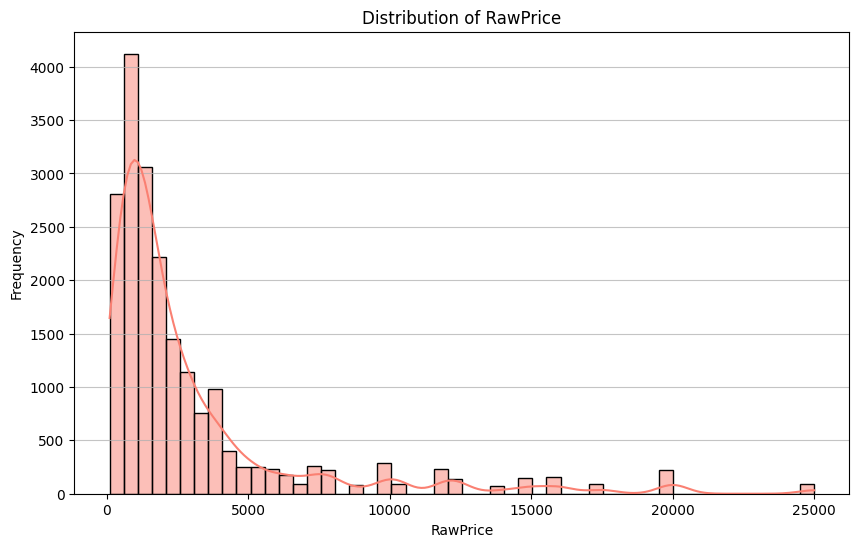

In [29]:
plt.figure(figsize=(10, 6))
sns.histplot(Transactions['RawPrice'], kde=True, bins=50, color='salmon')
plt.title('Distribution of RawPrice')
plt.xlabel('RawPrice')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [23]:
sample_means = []
num_samples = 1000
sample_size = 500

for _ in range(num_samples):
    # Take a sample of size 'sample_size' from 'RawPrice' column
    sample = Transactions['RawPrice'].sample(n=sample_size, random_state=None) # random_state=None ensures different samples each time
    # Calculate the mean of the current sample
    current_sample_mean = sample.mean()
    # Add the sample mean to our collection
    sample_means.append(current_sample_mean)

# Display the first few sample means to verify
print(f"First 5 sample means: {sample_means[:5]}")
print(f"Total number of sample means: {len(sample_means)}")

First 5 sample means: [np.float64(3169.578), np.float64(2950.874), np.float64(2917.518), np.float64(3060.002), np.float64(2663.556)]
Total number of sample means: 1000


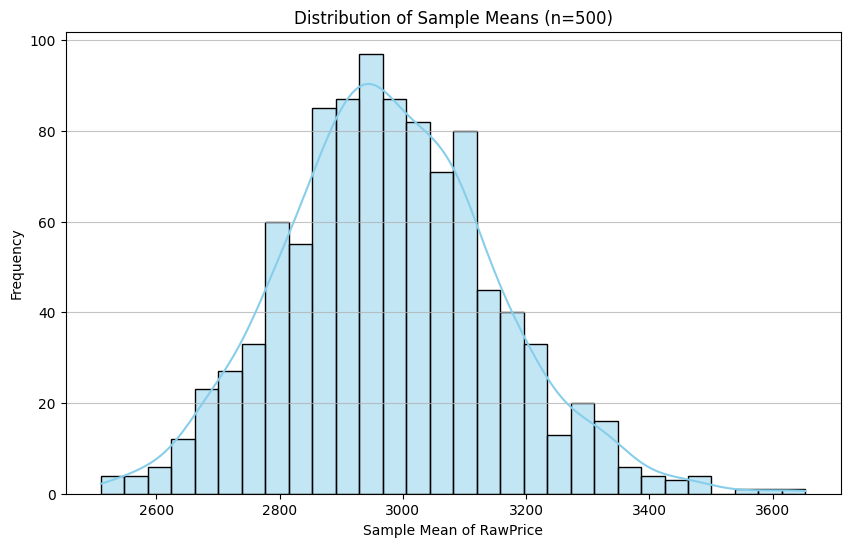

In [25]:
plt.figure(figsize=(10, 6))
sns.histplot(sample_means, kde=True, bins=30, color='skyblue')
plt.title('Distribution of Sample Means (n=500)')
plt.xlabel('Sample Mean of RawPrice')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [27]:
sample_means_series = pd.Series(sample_means)
print(sample_means_series.describe())

count    1000.000000
mean     2978.409276
std       172.032634
min      2510.082000
25%      2865.082000
50%      2968.780000
75%      3085.640000
max      3653.270000
dtype: float64


In [28]:
print(Transactions['RawPrice'].describe())

count    20000.000000
mean      2977.955700
std       3919.450919
min         99.000000
25%        799.000000
50%       1596.000000
75%       3196.000000
max      24995.000000
Name: RawPrice, dtype: float64
